In [ ]:
#part I:  Regression Task: Fuel Efficiency Prediction

#first, we must download the data, as such: (from https://archive.ics.uci.edu/dataset/9/auto+mpg)

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# # metadata
# print(auto_mpg.metadata)

# # variable information
# print(auto_mpg.variables)




In [ ]:
#2.1

#combine the features and targets into one
import pandas as pd

df = pd.concat([X, y], axis=1)

#quick overview of the data:
summary_table = df.describe().T
summary_table


,count,mean,std,min,25%,50%,75%,max
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


Missing values per feature:
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


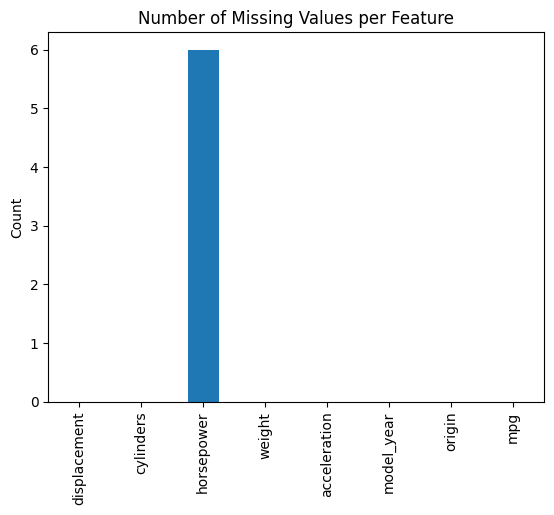

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#2.1

#i. missing features
df.isnull().sum()

missing = df.isnull().sum()

print("Missing values per feature:")
print(missing)

#now, to visualize:
missing = df.isnull().sum()

missing.plot(kind='bar')
plt.title("Number of Missing Values per Feature")
plt.ylabel("Count")
plt.show()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64


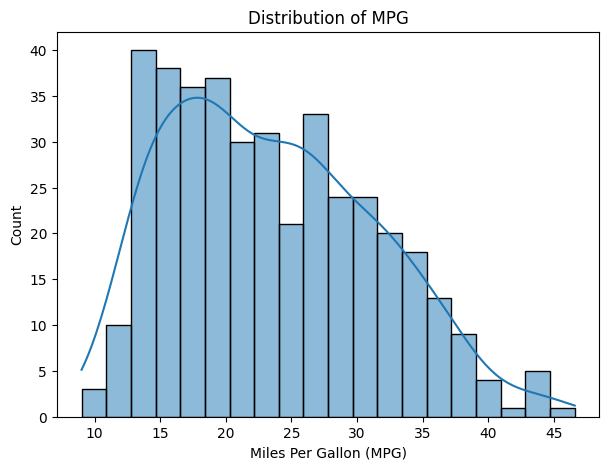

In [ ]:
#ii. distribution of the target variable (mpg)

print(df["mpg"].describe())

#visualize

plt.figure(figsize=(7,5))
sns.histplot(df["mpg"], bins=20, kde=True)
plt.xlabel("Miles Per Gallon (MPG)")
plt.title("Distribution of MPG")
plt.show()


                mpg
mpg           1.000
model_year    0.579
origin        0.563
acceleration  0.420
cylinders    -0.775
horsepower   -0.778
displacement -0.804
weight       -0.832


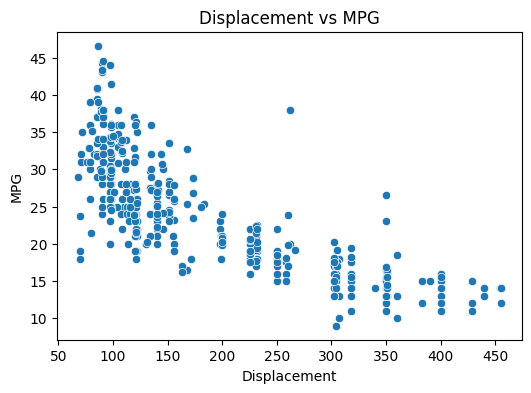

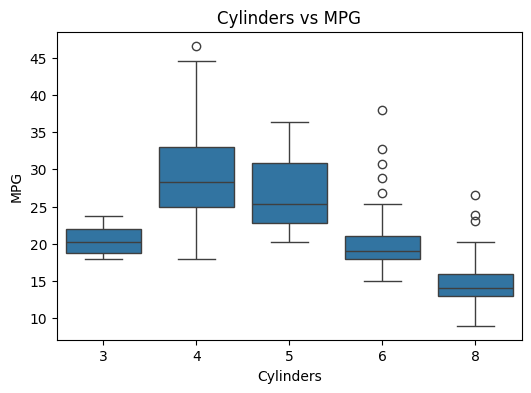

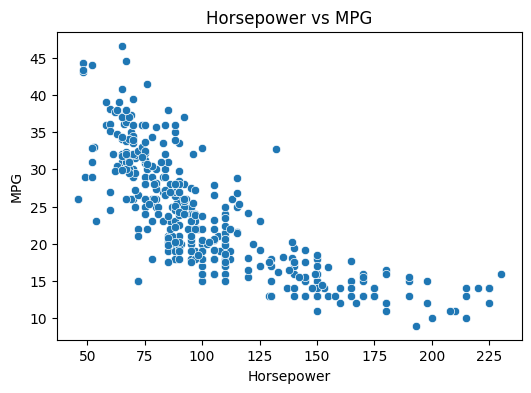

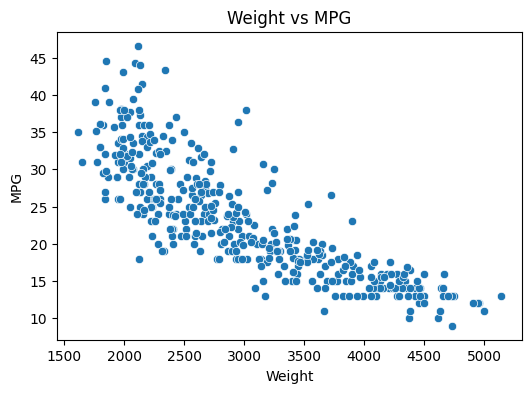

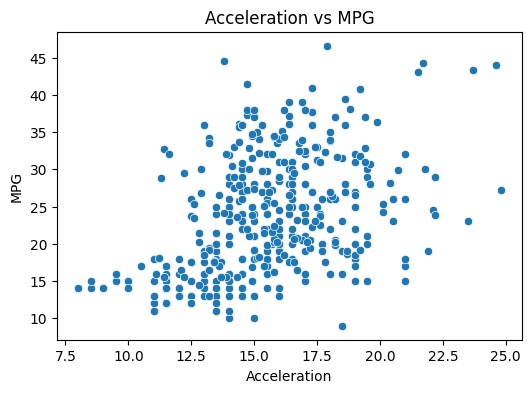

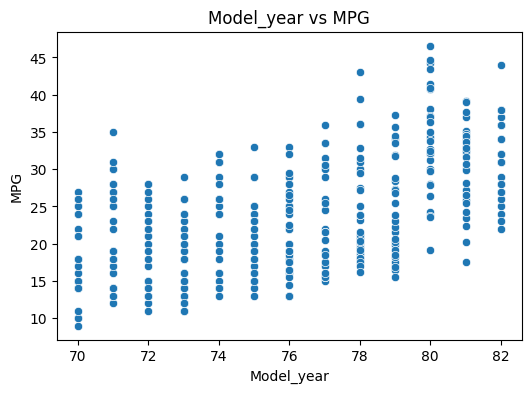

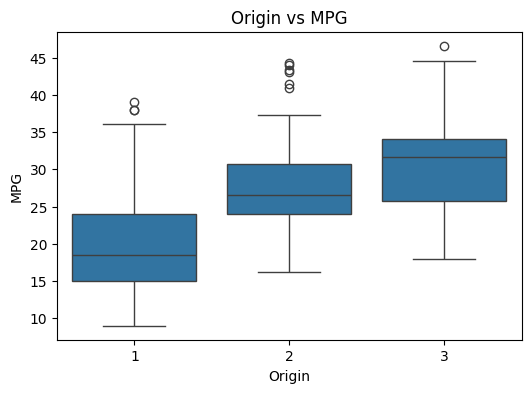

In [ ]:
#iii.  relationships between individual features and the target

#first, we'll observe the correclation:
corr_table = df.corr(numeric_only=True)[["mpg"]].sort_values(by="mpg", ascending=False).round(3)
print(corr_table)

#now, we plot every feature against mpg:

import matplotlib.pyplot as plt
import seaborn as sns

features = [col for col in df.columns if col != "mpg"]

for feature in features:
    plt.figure(figsize=(6,4))

    if df[feature].nunique() < 10:
        sns.boxplot(data=df, x=feature, y="mpg")
    else:
        sns.scatterplot(data=df, x=feature, y="mpg")

    plt.title(f"{feature.capitalize()} vs MPG")
    plt.xlabel(feature.capitalize())
    plt.ylabel("MPG")
    plt.show()


              displacement  cylinders  horsepower    weight  acceleration  \
displacement      1.000000   0.950721    0.897257  0.932824     -0.543684   
cylinders         0.950721   1.000000    0.842983  0.896017     -0.505419   
horsepower        0.897257   0.842983    1.000000  0.864538     -0.689196   
weight            0.932824   0.896017    0.864538  1.000000     -0.417457   
acceleration     -0.543684  -0.505419   -0.689196 -0.417457      1.000000   
model_year       -0.370164  -0.348746   -0.416361 -0.306564      0.288137   
origin           -0.609409  -0.562543   -0.455171 -0.581024      0.205873   
mpg              -0.804203  -0.775396   -0.778427 -0.831741      0.420289   

              model_year    origin       mpg  
displacement   -0.370164 -0.609409 -0.804203  
cylinders      -0.348746 -0.562543 -0.775396  
horsepower     -0.416361 -0.455171 -0.778427  
weight         -0.306564 -0.581024 -0.831741  
acceleration    0.288137  0.205873  0.420289  
model_year      1.000000

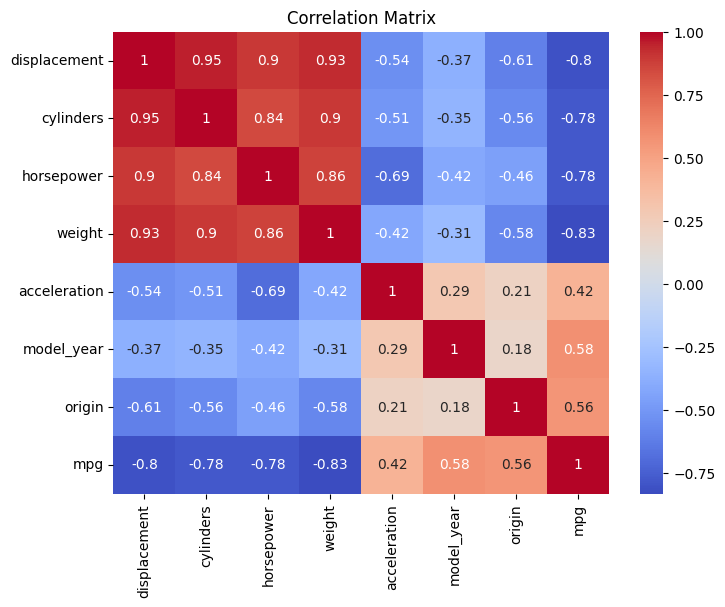

In [ ]:
#iv. correlations among features

#table
corr = df.corr(numeric_only=True)
print(corr)

#graph
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#2.2

#i. features used for prediction


In [ ]:
#ii. handling missing values

#we can remove missing values, because they make up a small portion of our data. as such, rows with missing values are removed entirely.

df = df.dropna()


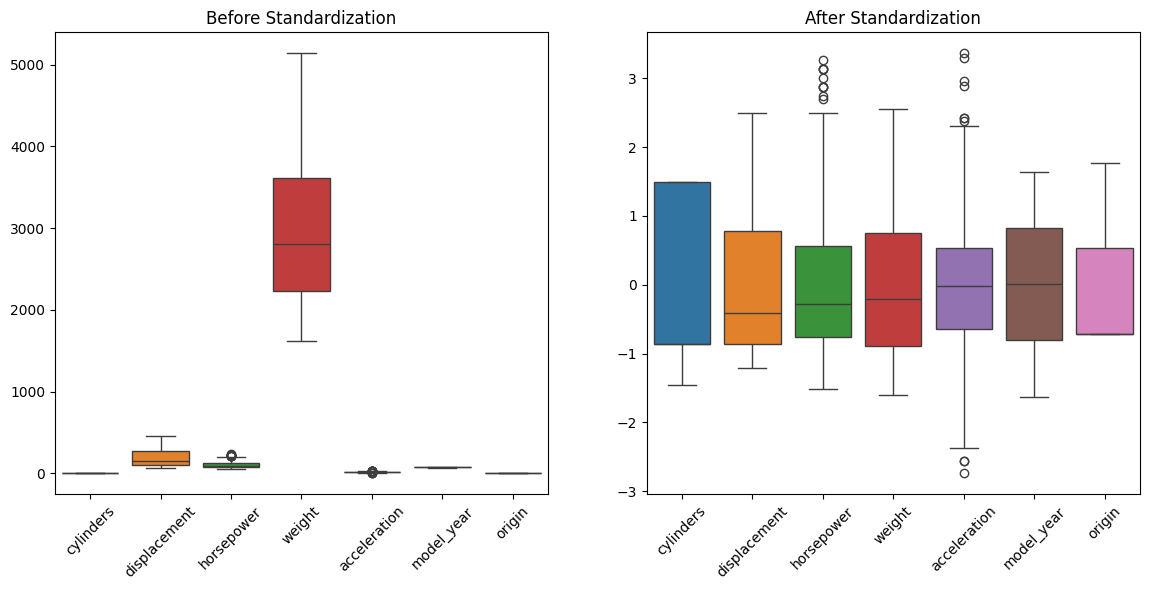

In [ ]:
#iii. feature standardization

# standardizing the features
from sklearn.preprocessing import StandardScaler

features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

X = df[features]
y = df["mpg"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#visual aid to show the impact:
from sklearn.preprocessing import StandardScaler

features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(X_scaled, columns=features)

fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.boxplot(data=df[features], ax=axes[0])
axes[0].set_title("Before Standardization")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=scaled_df, ax=axes[1])
axes[1].set_title("After Standardization")
axes[1].tick_params(axis='x', rotation=45)

plt.show()



In [ ]:
#2.3 linear regression

#first, we split the data into a train set and a test: NOTE 80-20 SPLIT

from sklearn.model_selection import train_test_split

features = ["weight", "horsepower", "model_year"]

X = df[features]
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)



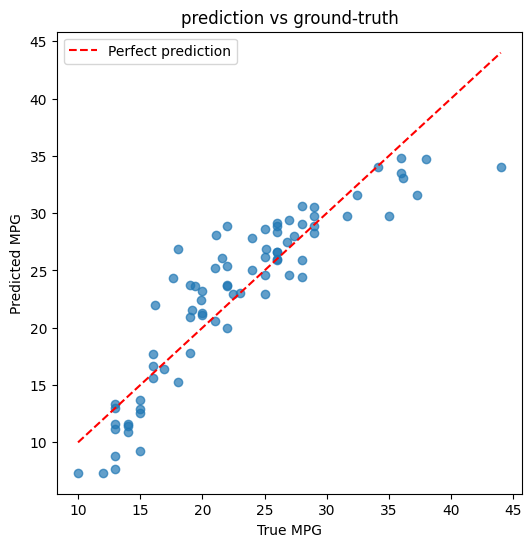

In [ ]:
#prediction vs ground truth

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.7)

# perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect prediction"
)

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("prediction vs ground-truth")
plt.legend()

plt.show()

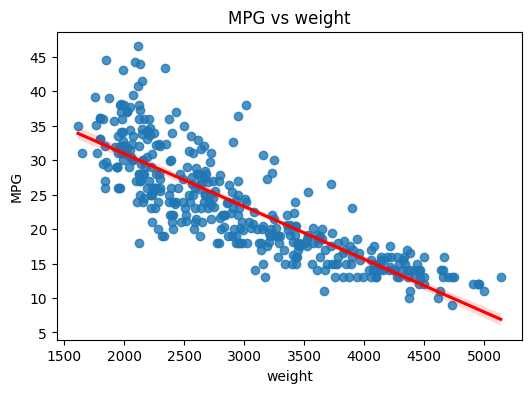

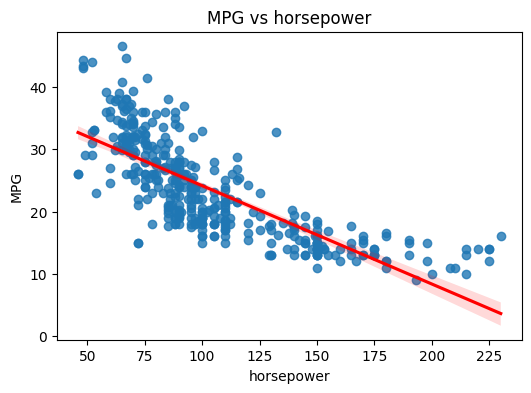

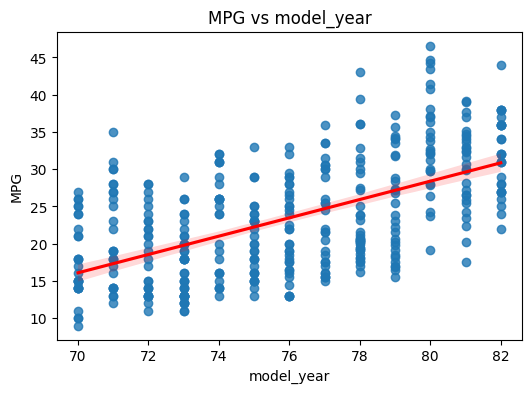

In [ ]:
#graph the features used vs mpg+ add linear line to compare

import seaborn as sns
import matplotlib.pyplot as plt

features = ["weight", "horsepower", "model_year"]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.regplot(
        x=df[feature],
        y=df["mpg"],
        line_kws={"color": "red"}
    )

    plt.title(f"MPG vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("MPG")

    plt.show()

In [ ]:
#evulation metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 10.596461113695385
RMSE: 3.255220593707189
MAE: 2.5089287137006546
R2: 0.7923914571293733


Degree 1
Train MSE: 11.960341964168759
Validation MSE: 10.596461113695382
Degree 2
Train MSE: 7.906367113265068
Validation MSE: 6.819684363413449
Degree 3
Train MSE: 7.079058840323346
Validation MSE: 5.707016964328276
Degree 4
Train MSE: 6.147533472863234
Validation MSE: 6.731950664410899
Degree 5
Train MSE: 5.687445043073753
Validation MSE: 6.878519515543699


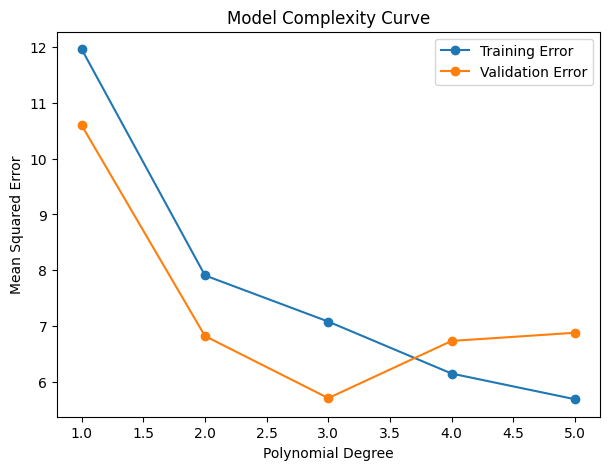

In [ ]:
#2.4 polynomial regression

#features used
features = ["weight", "horsepower", "model_year"]
df_clean = df.dropna().copy()
features = ["weight", "horsepower", "model_year"]

#clean
X = df_clean[features]
y = df_clean["mpg"]
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#degreen 1-5
degrees = [1,2,3,4,5]

train_mse = []
val_mse = []

for d in degrees:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_mse.append(mean_squared_error(y_train, train_pred))
    val_mse.append(mean_squared_error(y_val, val_pred))

    print(f"Degree {d}")
    print("Train MSE:", train_mse[-1])
    print("Validation MSE:", val_mse[-1])
    import matplotlib.pyplot as plt

#graph model complexity as function of d
plt.figure(figsize=(7,5))

plt.plot(degrees, train_mse, marker='o', label="Training Error")
plt.plot(degrees, val_mse, marker='o', label="Validation Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Model Complexity Curve")
plt.legend()

plt.show()


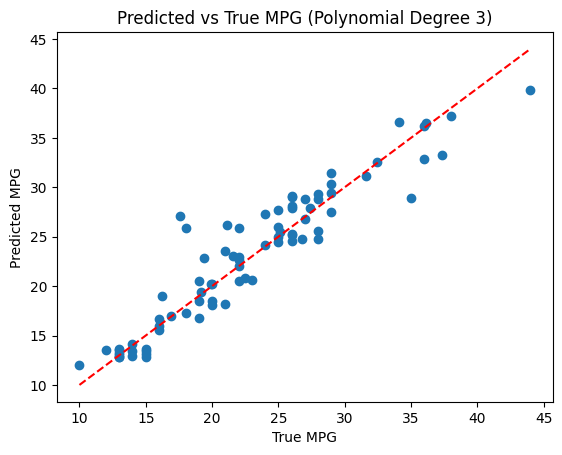

In [ ]:
#predict vs true for d3
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

model_d3 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("linear", LinearRegression())
])

model_d3.fit(X_train, y_train)

y_val_pred = model_d3.predict(X_val)


plt.scatter(y_val, y_val_pred)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("Predicted vs True MPG (Polynomial Degree 3)")
plt.show()

In [ ]:
#2.5 KNN

#prepare the data
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

#clean
df_clean = df.dropna().copy()

features = ["weight", "horsepower", "model_year"]

X = df_clean[features]
y = df_clean["mpg"]

#split data (80-20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#standartize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
#train k=1 to k=30

k_values = range(1, 31)

train_mse = []
val_mse = []

for k in k_values:

    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    val_pred = knn.predict(X_val_scaled)

    train_mse.append(mean_squared_error(y_train, train_pred))
    val_mse.append(mean_squared_error(y_val, val_pred))

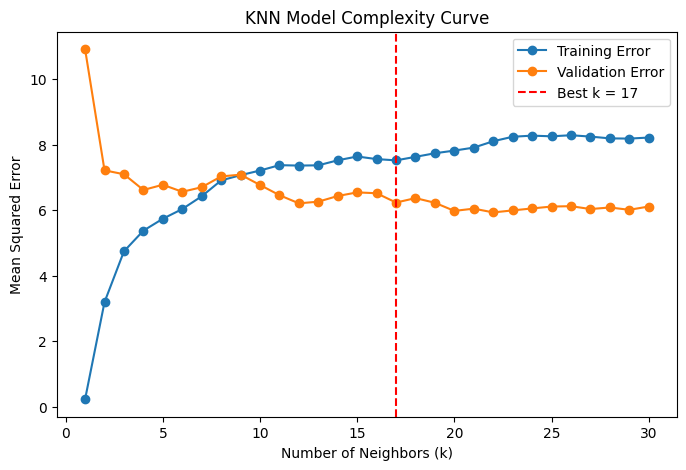

In [ ]:
#complexity curve as function of k

plt.figure(figsize=(8,5))

plt.plot(k_values, train_mse, marker='o', label="Training Error")
plt.plot(k_values, val_mse, marker='o', label="Validation Error")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error")
plt.title("KNN Model Complexity Curve")

best_k = k_values[np.argmin(cv_mse)]

plt.axvline(best_k, linestyle="--", color="red", label=f"Best k = {best_k}")
plt.legend()

plt.legend()
plt.show()

In [ ]:
#now to find best k (confirm graph results)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = range(1,31)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_mse = []
cv_mse = []

for k in k_values:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    #cross-validation error
    neg_mse_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_squared_error"
    )

    cv_error = -neg_mse_scores.mean()
    cv_mse.append(cv_error)

    #training error
    model.fit(X, y)
    train_pred = model.predict(X)
    train_error = mean_squared_error(y, train_pred)
    train_mse.append(train_error)

In [ ]:
best_k = k_values[np.argmin(cv_mse)]

print("Best k:", best_k)
print("Best CV MSE:", min(cv_mse))

Best k: 17
Best CV MSE: 8.122542552916693


In [ ]:
#now we train using the best k

final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k))
])

final_knn.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsRegressor(n_neighbors=17))])

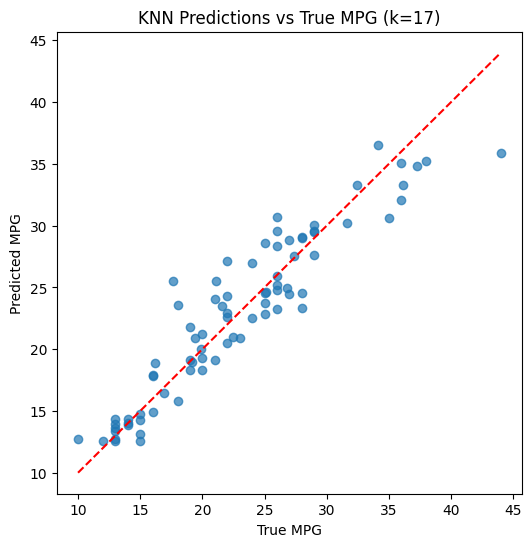

In [ ]:
#ground truth vs prediction for best k

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k))
])

best_knn_model.fit(X_train, y_train)

y_test_pred = best_knn_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title(f"KNN Predictions vs True MPG (k={best_k})")

plt.show()

In [ ]:
#2.6 optimization behavior

#prepare the data

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ["weight", "horsepower", "model_year"]

X = df_clean[features].values
y = df_clean["mpg"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

#now, add the bias term
X_train = np.c_[np.ones(len(X_train)), X_train]
X_val = np.c_[np.ones(len(X_val)), X_val]

In [ ]:
#define loss function

def mse(X, y, w):
    preds = X @ w
    return np.mean((preds - y) ** 2)

In [ ]:
#BGD

epochs = 100
lr = 0.01

w = np.zeros(X_train.shape[1])

train_loss_bgd = []
val_loss_bgd = []

for epoch in range(epochs):

    preds = X_train @ w
    gradient = 2 * X_train.T @ (preds - y_train) / len(y_train)

    w -= lr * gradient

    train_loss_bgd.append(mse(X_train, y_train, w))
    val_loss_bgd.append(mse(X_val, y_val, w))

In [ ]:
#SGD

epochs = 100
lr = 0.01

def mse(X, y, w):
    preds = X @ w
    return np.mean((preds - y) ** 2)

w = np.zeros(X_train.shape[1])

train_loss_sgd = []
val_loss_sgd = []

for epoch in range(epochs):

    for i in range(len(X_train)):
        xi = X_train[i]
        yi = y_train[i]

        gradient = 2 * xi * (xi @ w - yi)
        w -= lr * gradient

    train_loss_sgd.append(mse(X_train, y_train, w))
    val_loss_sgd.append(mse(X_val, y_val, w))


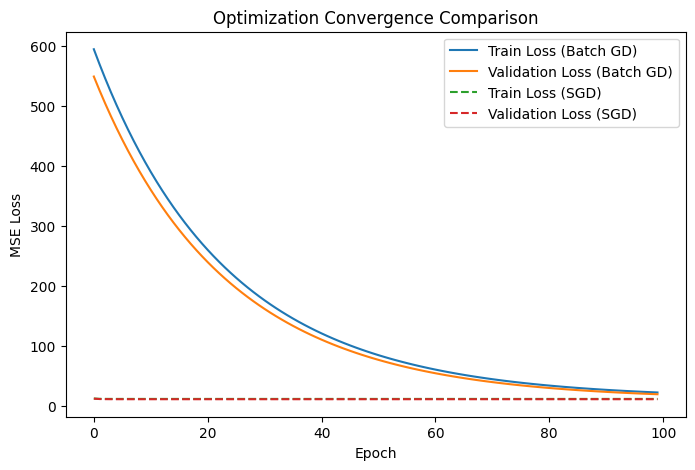

In [ ]:
#loss vs iterations graph

plt.figure(figsize=(8,5))

plt.plot(train_loss_bgd, label="Train Loss (Batch GD)")
plt.plot(val_loss_bgd, label="Validation Loss (Batch GD)")

plt.plot(train_loss_sgd, label="Train Loss (SGD)", linestyle='--')
plt.plot(val_loss_sgd, label="Validation Loss (SGD)", linestyle='--')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Optimization Convergence Comparison")

plt.legend()
plt.show()

In [ ]:
#2.7 model comparison and discussion

In [ ]:
#clean and split data

from sklearn.model_selection import train_test_split

X = df_clean[features]
y = df_clean["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#make pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("linear", LinearRegression())
])

In [ ]:
final_model.fit(X_train, y_train)
y_test_pred = final_model.predict(X_test)

In [ ]:
#evulation metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test MSE: 5.707016964328276
Test RMSE: 2.38893636673903
Test MAE: 1.6674358015036967
Test R2: 0.8881866820073718


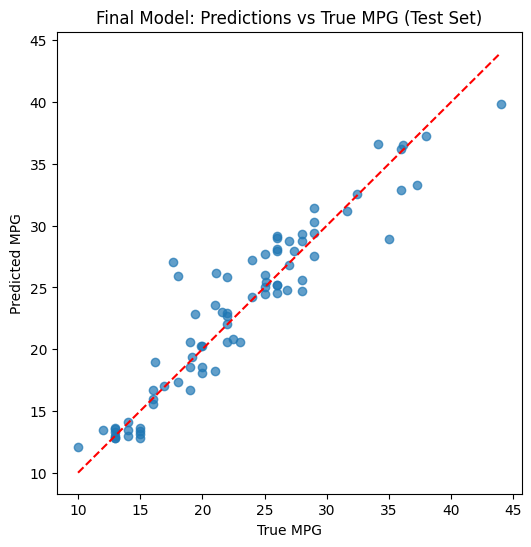

In [ ]:
#graph

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("Final Model: Predictions vs True MPG (Test Set)")

plt.show()

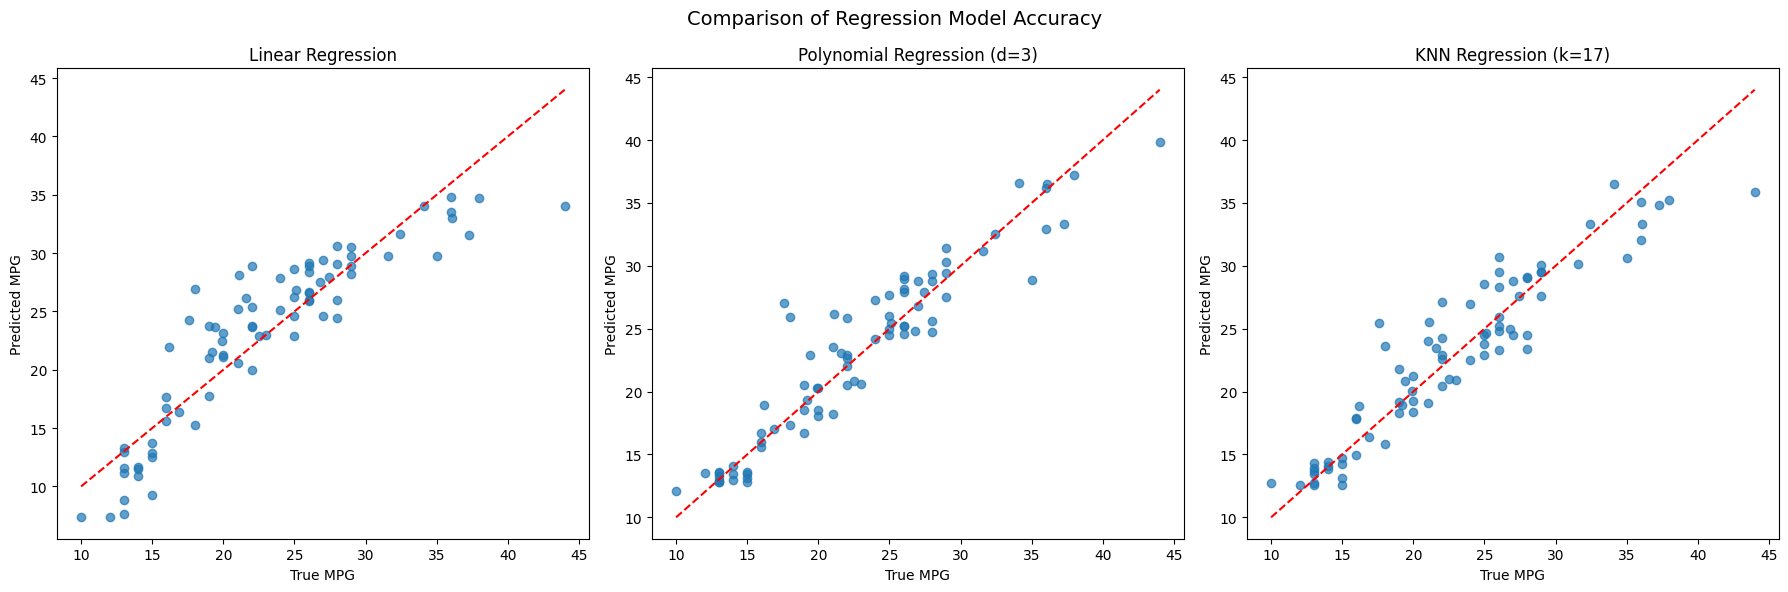

In [ ]:
#final graphs

import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

#linear regression
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

#polynomial regression

poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

#knn

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=17))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

#graphs

#comparison graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ("Linear Regression", y_pred_linear),
    ("Polynomial Regression (d=3)", y_pred_poly),
    ("KNN Regression (k=17)", y_pred_knn)
]

for ax, (title, y_pred) in zip(axes, models):
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )
    ax.set_title(title)
    ax.set_xlabel("True MPG")
    ax.set_ylabel("Predicted MPG")

plt.suptitle("Comparison of Regression Model Accuracy", fontsize=14)
plt.tight_layout()
plt.show()

                         Model      RMSE       MAE        R2
0            Linear Regression  3.255221  2.508929  0.792391
1  Polynomial Regression (d=3)  2.388936  1.667436  0.888187
2        KNN Regression (k=17)  2.495915  1.886299  0.877948


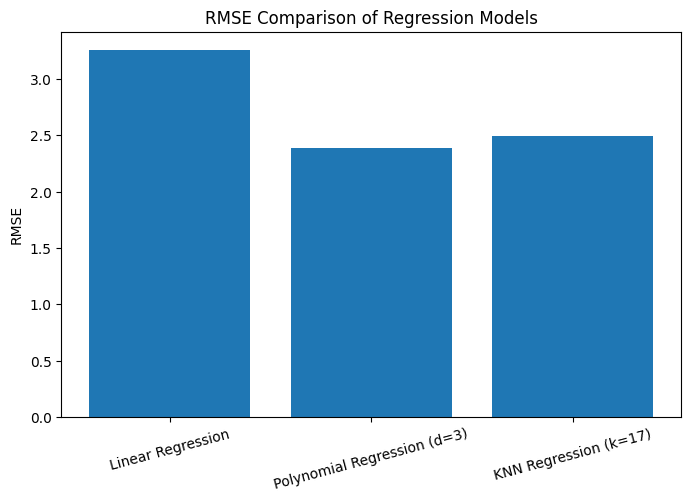

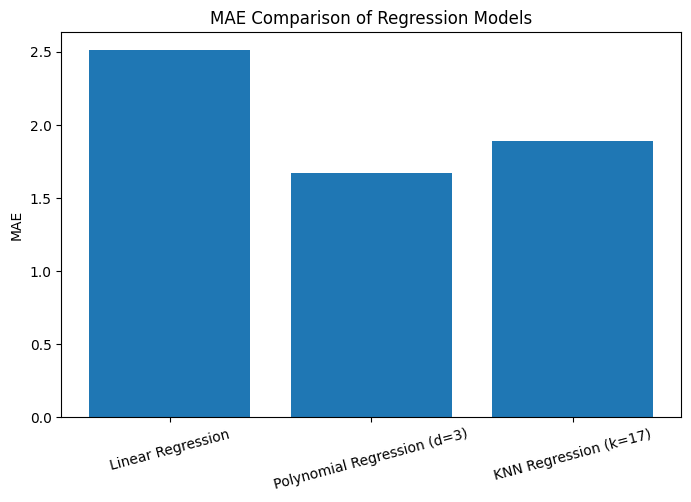

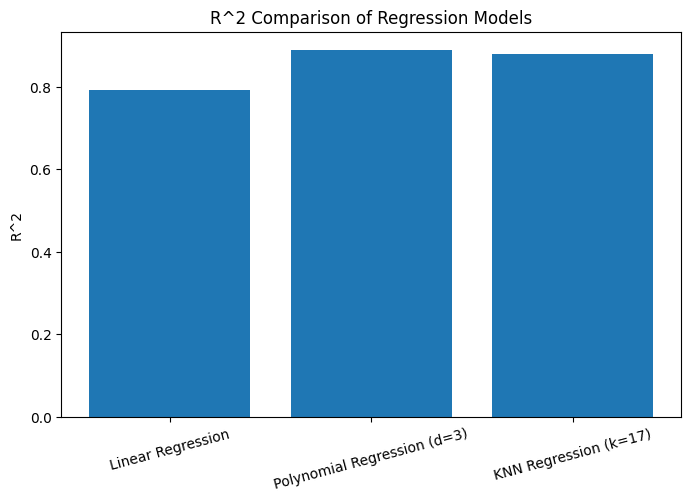

In [ ]:
#table + graphs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {
    "Model": [],
    "RMSE": [],
    "MAE": [],
    "R2": []
}

predictions = {
    "Linear Regression": y_pred_linear,
    "Polynomial Regression (d=3)": y_pred_poly,
    "KNN Regression (k=17)": y_pred_knn
}

for model_name, y_pred in predictions.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results["Model"].append(model_name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    results["R2"].append(r2)

#print table

results_df = pd.DataFrame(results)
print(results_df)

#RMSE comparison
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Regression Models")
plt.xticks(rotation=15)
plt.show()

#MAE comparison
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.ylabel("MAE")
plt.title("MAE Comparison of Regression Models")
plt.xticks(rotation=15)
plt.show()

#R^2 comparison
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2"])
plt.ylabel("R^2")
plt.title("R^2 Comparison of Regression Models")
plt.xticks(rotation=15)
plt.show()